### 0. Import packages

In [1]:
import logomaker
import glob as glob
import sys, os

os.path.dirname(sys.executable)

import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt

import sys, os, json, textwrap, itertools, requests
from pathlib import Path

from Bio.PDB import PDBParser, NeighborSearch, is_aa
from Bio.Data.IUPACData import protein_letters_3to1

import re
from typing import Optional          

from Bio.PDB import PDBParser, NeighborSearch
from scipy.spatial.distance import cdist



### 1. Exploration of structure-dervied peptides

In [22]:
def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = run_id
        
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        # print(f"Processed: {file_path}")

    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

# Example usage for RFdiffusion results
# results_dir = "/clusterfs/nilah/sergio/RFdifussion/outputs/EPITOPE_SERIES_20250416/*/af2.csv"
# results_files = glob.glob('/clusterfs/nilah/sergio/RFdifussion/7RTD/*/*.csv')

# # Define extra columns (e.g., extract contigs, iterations, num_seqs from run name)
# extra_columns = {
#     'contigs': lambda x: x.split('/')[-3].split('_C')[1].split('_I')[0],
#     'iterations': lambda x: x.split('_I')[1].split('_NS')[0],
#     'num_seqs': lambda x: x.split('_NS')[1].split('_')[0]
# }

# # Aggregate results
# results = aggregate_results(results_files, run_id_level=-2) #, extra_columns=extra_columns)

results = pd.read_csv('../data/HLAA0201_PDB_7RTD_RFdiffusion_sequences.csv')
results['epitope'] = results['seq'].apply(lambda x: x.split("/")[1])
results['length'] = results['epitope'].apply(lambda x: len(x))
results = results.drop_duplicates('epitope')

<Axes: >

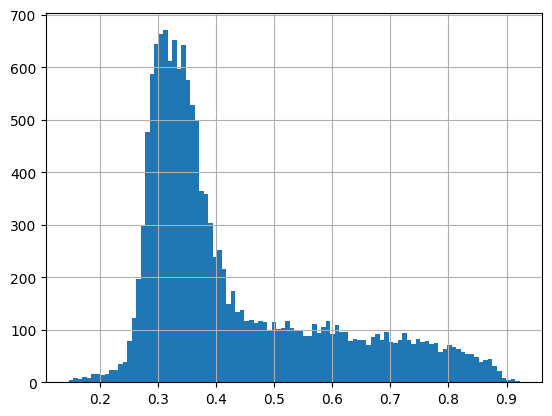

In [23]:
results['plddt'].hist(bins=100)

In [24]:
results = results.iloc[:, 1:]

In [ ]:
#dw.......lkfmqlk..dasdwqdwq

In [ ]:
# results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

results_meta = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz',compression='gzip')

results_meta['hla_allele'] = results_meta['title'].apply(grab_hla)
results_meta['hla_allele'] = results_meta['hla_allele'].str.replace('HLA','').str.replace('-','').str.replace(':','').str.replace('*','')

In [28]:
results_meta['epitope'] = results_meta['seq'].apply(lambda x: x.split("/")[1])
results_meta['length'] = results_meta['epitope'].apply(lambda x: len(x))

In [29]:
results_meta[['PDB', 'length','hla_allele','RUN']].drop_duplicates('RUN').groupby(['PDB','hla_allele'])['RUN'].size().reset_index().sort_values(by='RUN', ascending=False).head(15)

,PDB,hla_allele,RUN
1,3KPN,B4403,152
5,3TO2,A0201,148
2,3KPO,B4403,147
15,3VFW,B3508,145
0,1SYV,B4405,142
10,3VFR,B3508,138
7,3VFN,B3508,137
14,3VFV,B3508,137
6,3VFM,B3508,135
8,3VFO,B3508,135


In [30]:
results_meta[['PDB', 'length','hla_allele']].drop_duplicates().groupby(['PDB','hla_allele'])['length'].size().reset_index(name='length_sizes').sort_values('length_sizes', ascending=False).head(15)

,PDB,hla_allele,length_sizes
11,3VFS,B3508,7
53,6VQD,B2705,7
6,3VFM,B3508,7
7,3VFN,B3508,7
8,3VFO,B3508,7
9,3VFP,B3508,7
10,3VFR,B3508,7
68,7KGT,A0201,7
12,3VFT,B3508,7
13,3VFU,B3508,7


In [31]:
results_meta[results_meta['hla_allele'] == 'HLA-A*0201']['PDB'].unique()


array([], dtype=object)

In [32]:
# results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

In [33]:
results_meta[results_meta['PDB'] == '6VB4']['title'].values[0]

'HLA-B*1502 complexed with a synthetic peptide'

In [34]:
results_meta = results_meta.drop_duplicates(['pdb_id', 'epitope'])

In [35]:
# results_meta.to_csv('rdfiffusion_output_peptides.csv', index=False)
results_meta['hla_allele'].unique()

array(['B5301', 'B2705', 'B1502', None, 'N0101', 'B5703', 'B8', 'A0201',
       'B1801', 'B3501', 'A2402', 'B4403', 'B3508', 'B1301', 'A2',
       'B4405', 'B5801', 'B3505', 'B1501', 'A6', 'A0206', 'A0207',
       'B4001', 'B5803', 'B5701', 'C1203', 'C1202', 'B2706', 'B3503'],
      dtype=object)

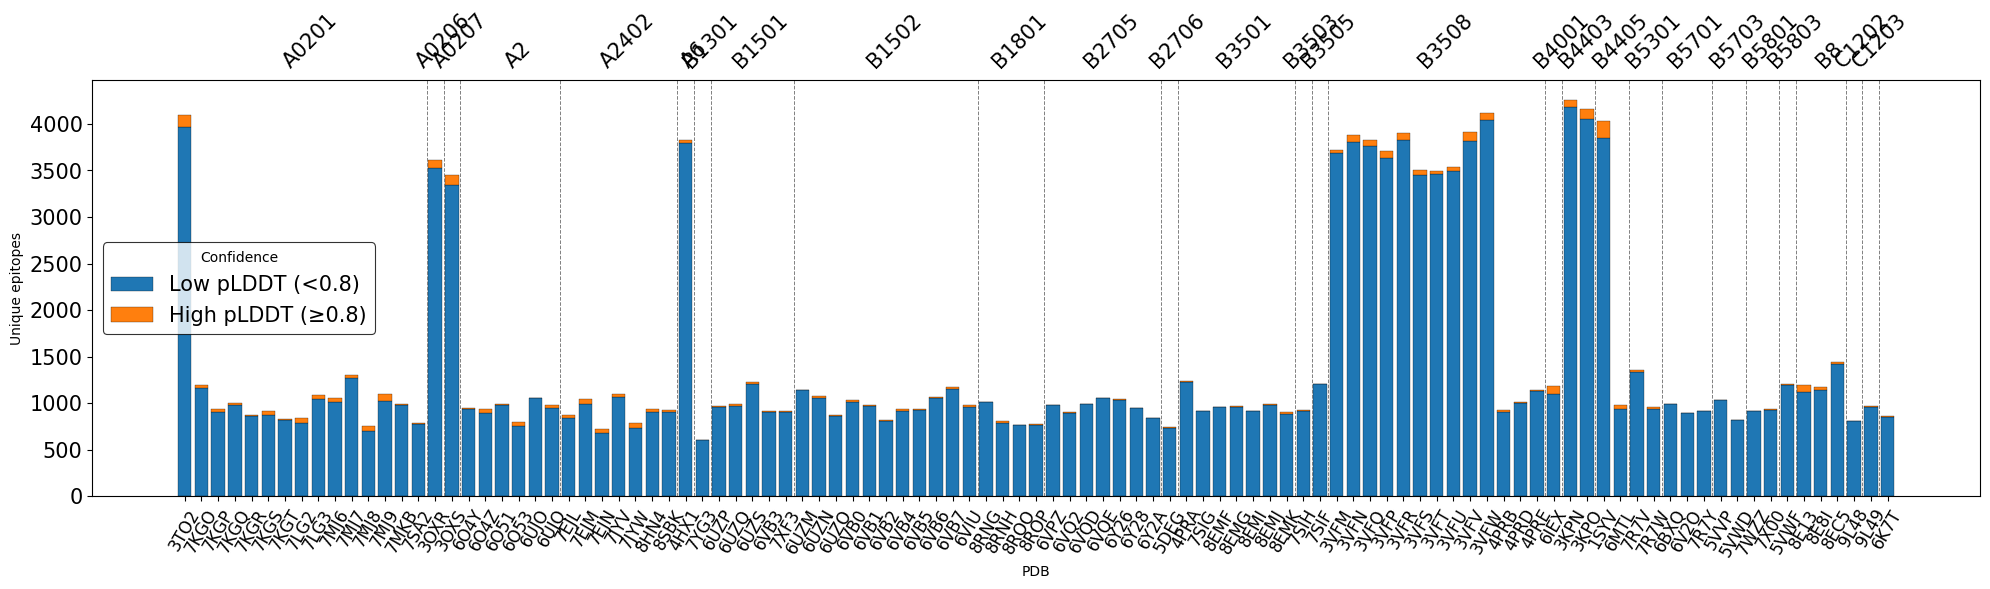

In [ ]:

# ------------------------------------------------------------------
# 1.  Build a long table with a confidence label
# ------------------------------------------------------------------
tmp = (
    results_meta
      .drop_duplicates(subset=['epitope', 'PDB'])           # one epitope / PDB
      .assign(conf=lambda d: np.where(d['plddt'] >= 0.8,
                                      'High pLDDT (≥0.8)',
                                      'Low pLDDT (<0.8)'))
)

counts = (tmp
          .groupby(['hla_allele', 'PDB', 'conf'])
          .size()
          .reset_index(name='num_epitopes'))

# ------------------------------------------------------------------
# 2.  Order bars: hla_allele blocks, then TOTAL-count desc. within each block
# ------------------------------------------------------------------
# 2-a. get total per PDB to sort inside each allele block
total = (counts.groupby(['hla_allele', 'PDB'])['num_epitopes']
               .sum()
               .reset_index(name='total_epitopes'))

counts = counts.merge(total, on=['hla_allele', 'PDB'])

counts = (counts
          .sort_values(['hla_allele', 'total_epitopes'],
                       ascending=[True, False])
          .reset_index(drop=True))

# track allele boundaries
allele_boundary = counts[['hla_allele', 'PDB']].drop_duplicates()
allele_boundary['group_idx'] = allele_boundary['hla_allele'].ne(
                                   allele_boundary['hla_allele'].shift()
                               ).cumsum()
counts = counts.merge(allele_boundary, on=['hla_allele', 'PDB'])

bar_order = allele_boundary['PDB'].tolist()        # order for plotting

# ------------------------------------------------------------------
# 3.  Pivot to wide form for a manual stacked plot
# ------------------------------------------------------------------
wide = (counts
        .pivot_table(index=['hla_allele', 'PDB', 'group_idx'],
                     columns='conf',
                     values='num_epitopes',
                     fill_value=0)
        .reset_index())

# guarantee both columns exist even if one tier is missing
for c in ['High pLDDT (≥0.8)', 'Low pLDDT (<0.8)']:
    if c not in wide.columns:
        wide[c] = 0

# ------------------------------------------------------------------
# 4.  Draw stacked bars
# ------------------------------------------------------------------
plt.figure(figsize=(20, 6))

bottom = np.zeros(len(wide))
colors = ['tab:blue', 'tab:orange']   # low first (bottom), high on top
labels = ['Low pLDDT (<0.8)', 'High pLDDT (≥0.8)']

for col, color, lab in zip(labels, colors, labels):
    plt.bar(
        x=wide['PDB'],
        height=wide[col],
        bottom=bottom,
        color=color,
        label=lab,
        edgecolor='black',
        linewidth=0.2
    )
    bottom += wide[col].values

plt.xticks(rotation=60, fontsize=12)
plt.yticks(fontsize=15)
plt.ylabel('Unique epitopes')
plt.xlabel('PDB')

plt.legend(
    title='Confidence',
    frameon=True,              # draw a legend box
    fontsize=15
)

# give that box a white fill and a thin black border
leg = plt.gca().get_legend()
leg.get_frame().set_facecolor('white')   # white background
leg.get_frame().set_edgecolor('black')   # optional: black outline
leg.get_frame().set_linewidth(0.8)


# ------------------------------------------------------------------
# 5.  Add vertical separators + allele labels
# ------------------------------------------------------------------
group_sizes = wide.groupby('group_idx').size().cumsum().values[:-1]

for xc in group_sizes:
    plt.axvline(x=xc - 0.5, color='grey', linestyle='--', lw=0.7)

midpoints = np.insert(group_sizes, 0, 0)
midpoints = (midpoints[:-1] + group_sizes) / 2
for xmid, allele in zip(midpoints, wide['hla_allele'].unique()):
    plt.text(xmid, plt.ylim()[1] * 1.02, allele,
             ha='center', va='bottom', fontsize=15, rotation=45)
             
plt.tight_layout()
plt.show()


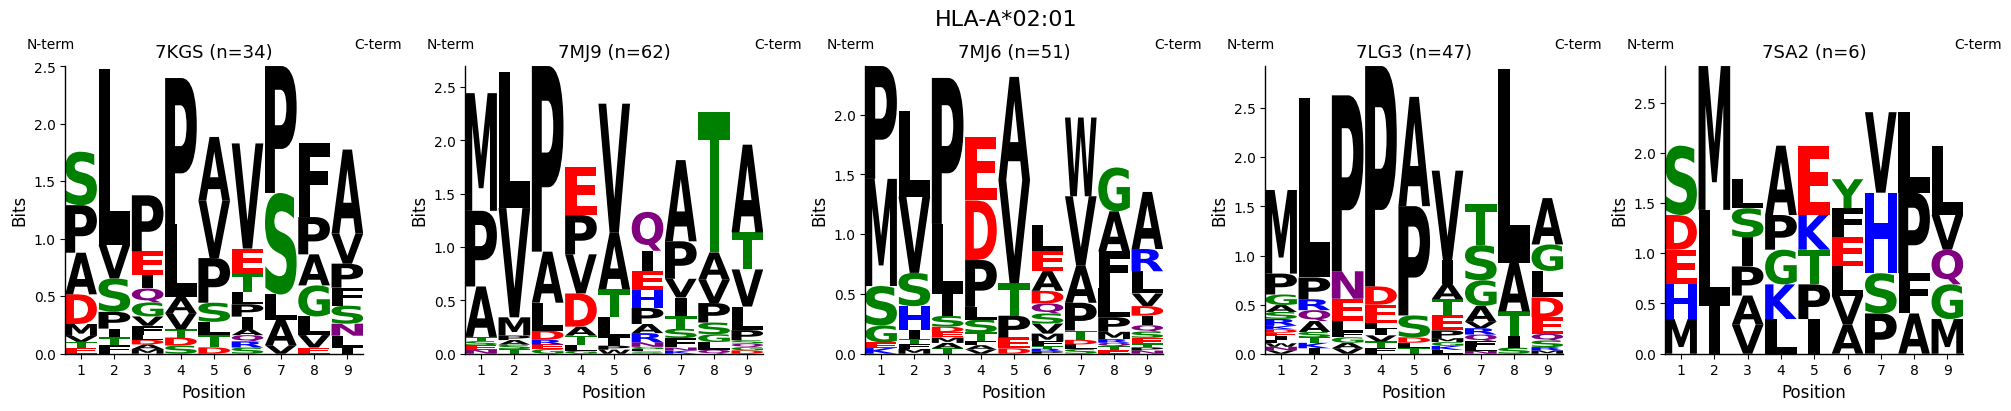

In [39]:
allele      = 'A*02:01'
pdbs        = ['7KGS', '7MJ9', '7MJ6', '7LG3', '7SA2'] #['7KGS', '7MJ9', '7MJ6', '7LG3', '7SA2'] # ['6UZS', '6VB3', '6UZQ', '7XF3'] #results_meta[results_meta['hla_allele'] == allele]['PDB'].unique() #['6UZS', '7XF3', '6VB3', '6UZQ'] #['7KGS', '7MJ9', '7MJ6', '7LG3', '7SA2'] #results_meta[results_meta['hla_allele'] == allele]['PDB'].unique()[7:] 
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
n = 9   # only 9-mers

fig, axes = plt.subplots(1, len(pdbs), figsize=(20, 4), constrained_layout=True)
found = False

for ax, pdb in zip(axes, pdbs):
    mask = (
        (results_meta['PDB'] == pdb) &
        (results_meta['epitope'].str.len() == n) &
        (results_meta['plddt'] >= 0.7)
    )
    entries = results_meta.loc[mask, 'epitope'].drop_duplicates()
    seqs    = entries.tolist()
    
    if not seqs:
        ax.axis('off')
        ax.set_title(f"{pdb}\n(no {n}-mers)", fontsize=12)
        continue

    found = True
    # count matrix
    count_mat = np.zeros((n, len(amino_acids)), dtype=float)
    for seq in seqs:
        for pos, aa in enumerate(seq):
            try:
                idx = amino_acids.index(aa)
            except ValueError:
                continue
            count_mat[pos, idx] += 1

    # frequencies
    freq_mat = count_mat / count_mat.sum(axis=1, keepdims=True)
    freq_df  = pd.DataFrame(freq_mat, columns=amino_acids)

    # uniform background array
    bg_array = [1/20] * len(amino_acids)

    # information content
    info_df = logomaker.transform_matrix(
        freq_df,
        from_type='probability',
        to_type='information',
        background=bg_array
    )

    # draw the logo
    logo = logomaker.Logo(
        info_df,
        ax=ax,
        color_scheme='chemistry',
    )
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left','bottom'], visible=True)

    # X ticks and labels
    ax.set_xticks(range(n))
    ax.set_xticklabels([str(i+1) for i in range(n)])
    ax.set_xlabel("Position", fontsize=12)
    ax.set_ylabel("Bits", fontsize=12)

    # annotate N- and C-termini
    ax.text(
        -0.2, 1.05, "N-term",
        transform=ax.get_xaxis_transform(),
        ha='right', va='bottom', fontsize=10
    )
    ax.text(
        n-0.8, 1.05, "C-term",
        transform=ax.get_xaxis_transform(),
        ha='left', va='bottom', fontsize=10
    )

    # only PDB + peptide count in title
    ax.set_title(f"{pdb} (n={len(seqs)})", fontsize=13)

# save/show
if found:
    output_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/figures/'
    os.makedirs(output_dir, exist_ok=True)
    fig.suptitle(
        f"HLA-{allele}",
        fontsize=16
    )
    fig.savefig(
        os.path.join(output_dir, f'{allele}_9mer_info_logo.pdf'),
        bbox_inches='tight'
    )
    plt.show()
else:
    plt.close(fig)


In [ ]:
from collections import Counter
from itertools import combinations
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon

# keep only one copy of each (pdb_id, epitope) pair
peptides_by_pdb = (
    results_meta[(results_meta['plddt'] > 0.8) ] # & (results_meta['length'] == 11)]
    .loc[:, ['pdb_id', 'epitope']]
    .drop_duplicates()
    .groupby('pdb_id')['epitope']
    .apply(list)
)
pdb_ids = peptides_by_pdb.index.tolist()

AA = "ACDEFGHIKLMNPQRSTVWY"

def build_pwm(seqs, max_len=10):
    """
    Return a (L × 20) frequency matrix, padding shorter peptides
    with '-' and ignoring them in the counts.
    """
    if not seqs:
        return np.zeros((max_len, 20))
    L = max_len
    mat = np.zeros((L, 20))
    for s in seqs:
        for i, aa in enumerate(s):
            if i >= L: break
            j = AA.index(aa)
            mat[i, j] += 1
    # convert to prob’s (add pseudocount to avoid 0)
    mat += 1e-6
    mat /= mat.sum(axis=1, keepdims=True)
    return mat

# build a PWM per PDB
pwms = {pdb: build_pwm(peps) for pdb, peps in peptides_by_pdb.items()}

def pwm_distance(M1, M2, metric="js"):
    if metric == "js":       # Jensen–Shannon divergence averaged over positions
        return np.mean([jensenshannon(M1[i], M2[i]) for i in range(M1.shape[0])])
    elif metric == "l1":     # simple L1 difference
        return np.sum(np.abs(M1 - M2))
    elif metric == "euclid": # Euclidean distance averaged over positions
        return np.mean([np.linalg.norm(M1[i] - M2[i]) for i in range(M1.shape[0])])
    else:
        raise ValueError("metric must be 'js', 'l1' or 'euclid'")

def pwm_distance_matrix(metric="js"):
    n = len(pdb_ids)
    D = np.zeros((n, n))
    for i, j in combinations(range(n), 2):
        d = pwm_distance(pwms[pdb_ids[i]], pwms[pdb_ids[j]], metric)
        D[i, j] = D[j, i] = d
    return pd.DataFrame(D, index=pdb_ids, columns=pdb_ids)

pwm_js   = pwm_distance_matrix(metric="js")   # divergence    (0 == identical)
pwm_l1   = pwm_distance_matrix(metric="l1")   # absolute diff (0 == identical)
pwm_euclid = pwm_distance_matrix(metric="euclid")  # Euclidean

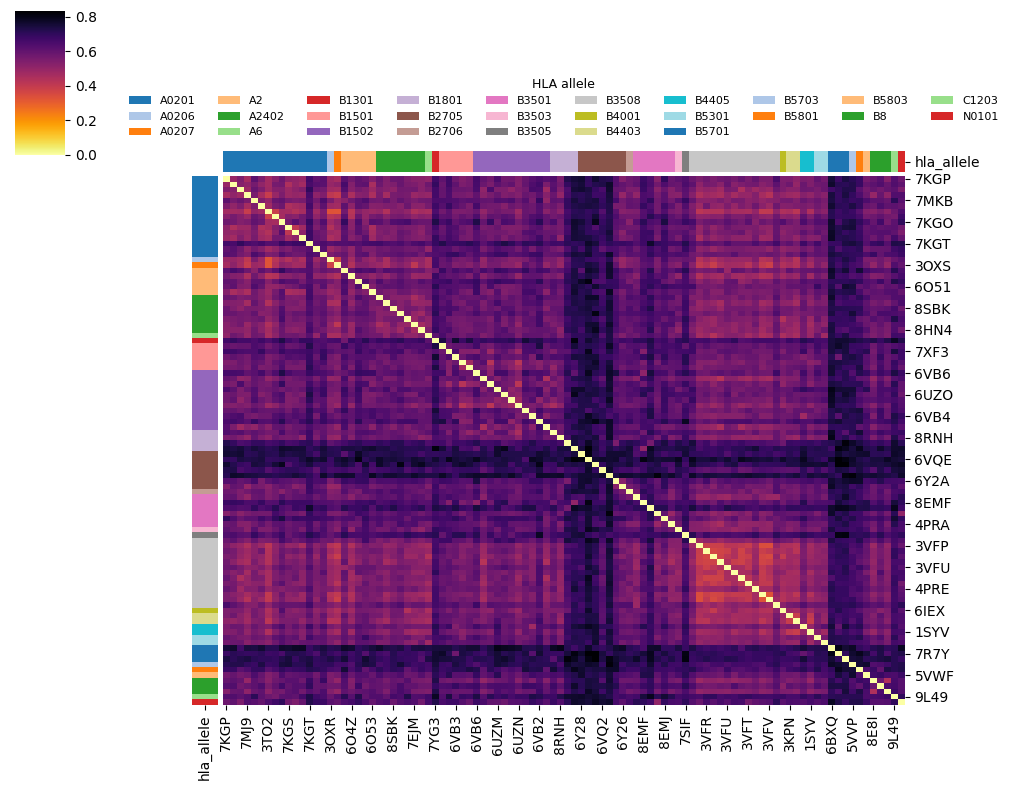

In [ ]:
# -------------------------------------------------------------
# 1 .  Map every PDB to its HLA allele
# -------------------------------------------------------------
# results_meta must contain a column named 'hla_allele' (grab_hla() gave you that).
pdb2hla = (
    results_meta[['pdb_id', 'hla_allele']]
    .dropna()
    .drop_duplicates(subset='pdb_id')
    .set_index('pdb_id')['hla_allele']
)

# fallback label for structures where HLA wasn’t detected
pwm_euclid = pwm_euclid.loc[pdb2hla.index.intersection(pwm_euclid.index)]  # keep only mapped PDBs
pdb2hla = pdb2hla.reindex(pwm_euclid.index).fillna('UNK')

# -------------------------------------------------------------
# 2 .  Re-order the matrix by HLA group, then by PDB
# -------------------------------------------------------------
order = (
    pdb2hla
    .sort_values(kind='mergesort')  # stable: keeps original PDB order within HLA block
    .index
)

M = pwm_js.loc[order, order]            # reordered similarity matrix
hla_order = pdb2hla.loc[order]          # parallel HLA list

# -------------------------------------------------------------
# 3 .  Build stripe colours for the clustermap
# -------------------------------------------------------------
unique_hla = hla_order.unique()
palette    = sns.color_palette('tab20', len(unique_hla))
color_map  = dict(zip(unique_hla, palette))
row_colors = hla_order.map(color_map)

# -------------------------------------------------------------
# 4 .  Draw the heatmap
# -------------------------------------------------------------
g = sns.clustermap(
        M,
        cmap='inferno_r',
        row_cluster=False,
        col_cluster=False,
        row_colors=row_colors,
        col_colors=row_colors,
        linewidths=0.0,  # no tiny grid lines
        figsize=(10, 8)
    )

# -------------------------------------------------------------
# 5 .  Add bold white lines between HLA blocks
# -------------------------------------------------------------
# Find cumulative sizes of each HLA group
group_sizes = hla_order.value_counts(sort=False).loc[unique_hla].values
cuts = np.cumsum(group_sizes)

for cut in cuts[:-1]:                       # skip last cumulative (matrix edge)
    g.ax_heatmap.axhline(cut,  color='white', lw=0)
    g.ax_heatmap.axvline(cut,  color='white', lw=0)

# -------------------------------------------------------------
# 6 .  Pretty titles & legend
# -------------------------------------------------------------
# g.ax_heatmap.set_title('PWM-L1 dissimilarity of peptide sets (grouped by HLA)', pad=16)

# Build a tiny legend for the stripe colours
for hla, col in color_map.items():
    g.ax_col_dendrogram.bar(0, 0, color=col, label=hla, linewidth=0)
g.ax_col_dendrogram.legend(
    loc='lower center',
    ncol=10,
    title='HLA allele',
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

plt.show()

In [42]:
from scipy.spatial.distance import jensenshannon
from Bio import pairwise2                         # Biopython local-align for unequal lengths

# -----------------------------------------------------------------------------------
# Part A – counts per allele / pLDDT tier
# -----------------------------------------------------------------------------------
# 1. mark confidence tier (your tmp DataFrame)
tmp = (
    results_meta
      .drop_duplicates(subset=['epitope', 'PDB'])
      .assign(conf=lambda d: np.where(d['plddt'] >= 0.8,
                                      'HIGH_PLDDT', 'LOW_PLDDT'))
)

# 2. peptide counts per allele + tier
epi_counts = (tmp.groupby(['hla_allele', 'conf'])
                   .size().reset_index(name='n_epitopes'))

# 3. number of distinct PDBs per allele
struct_counts = (tmp.groupby('hla_allele')['PDB']
                     .nunique()
                     .reset_index()
                     .rename(columns={'PDB': 'n_structures'}))

# 4. merge & pivot into final summary table
allele_summary = (struct_counts
                  .merge(epi_counts, on='hla_allele', how='left')
                  .pivot_table(index=['hla_allele', 'n_structures'],
                               columns='conf',
                               values='n_epitopes',
                               fill_value=0)
                  .reset_index()
                  .sort_values('n_structures', ascending=False))

# 5. save & show
# out_csv = '/global/scratch/users/sergiomar10/ESMCBA/analysis/allele_summary.csv'
# allele_summary.to_csv(out_csv, index=False)
# display(allele_summary.head())


/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [43]:
allele_summary['sum'] = allele_summary['HIGH_PLDDT'].astype(int) + allele_summary['LOW_PLDDT'].astype(int)

In [44]:
allele_summary

conf,hla_allele,n_structures,HIGH_PLDDT,LOW_PLDDT,sum
0,A0201,15,619.0,17163.0,17782
15,B3508,13,690.0,40004.0,40694
8,B1502,11,153.0,10872.0,11025
4,A2402,7,266.0,6127.0,6393
12,B3501,7,51.0,6838.0,6889
10,B2705,7,29.0,6739.0,6768
3,A2,6,141.0,5574.0,5715
7,B1501,5,67.0,4962.0,5029
9,B1801,4,37.0,3339.0,3376
24,B8,3,128.0,3675.0,3803


### 3. Load predictions from the models

In [45]:
# df_merged_combined = pd.concat([df_merged_low, df_merged])
# df_long2['Binders'] = 'Plddt < 0.2'
# df_long['Binders'] = 'Plddt > 0.8'
# df_long_plot = pd.concat([df_long, df_long2])
# model_map = {
#     'pred_hla':            'ESMCBA (HLA)',
#     'pred_epitope':        'ESMCBA (Epitope)',
#     'mhcflurry_affinity':  'MHCflurry',
#     'netmhc_rank':         'NetMHCpan'
# }
# df_long_plot['Model'] = df_long_plot['Model'].map(model_map)
# add_plot_df = pd.merge(df_long_plot, results, left_on='sequence', right_on='epitope', how='left')
# # sns.scatterplot(data=add_plot_df, x='plddt', y='Value', hue='Model', alpha=0.5)
# sns.scatterplot(data=add_plot_df, x='i_ptm', y='Value', hue='Model', alpha=0.5)
# sns.scatterplot(data=add_plot_df, x='mpnn', y='Value', hue='Model', alpha=0.5)
# sns.scatterplot(data=add_plot_df, x='i_pae', y='Value', hue='Model', alpha=0.5)
# sns.scatterplot(data=add_plot_df, x='mpnn', y='Value', hue='Model', alpha=0.5)
# add_plot_df[add_plot_df['plddt'] > 0.8]
# sns.scatterplot(data=add_plot_df[add_plot_df['plddt'] > 0.85], x='plddt', y='Value', hue='Model', alpha=0.5)
# add_plot_df[add_plot_df['plddt'] < 0.1]
# sns.scatterplot(data=add_plot_df[add_plot_df['plddt'] < 0.2], x='plddt', y='Value', hue='Model', alpha=0.5)
# from scipy.stats import mannwhitneyu

# median_table = (
#     df_long_plot
#     .groupby(["Model", "Binders"])["Value"]
#     .median()
#     .reset_index(name="median_Value")
# )

# # 2) Compute p-values per Model (high vs low confidence)
# pvals = []
# for model in df_long_plot["Model"].unique():
#     dfm = df_long_plot[df_long_plot["Model"] == model]
#     grp_high = dfm[dfm["Binders"] == "Plddt > 0.8"]["Value"]
#     grp_low  = dfm[dfm["Binders"] != "Plddt > 0.8"]["Value"]  # adjust label if needed
#     if len(grp_high) > 0 and len(grp_low) > 0:
#         stat, p = mannwhitneyu(grp_high, grp_low, alternative="two-sided")
#     else:
#         p = float("nan")
#     pvals.append({"Model": model, "p_value": p})

# pvals_df = pd.DataFrame(pvals)

# # Merge p-values into median table
# median_with_p = median_table.merge(pvals_df, on="Model")
# print("Median predicted values and p-values by Model and Binders:")
# # print(median_with_p )

# # 3) Violin plot with p-value annotations
# sns.set_style("white")
# fig, ax = plt.subplots(figsize=(10, 6))
# sns.violinplot(
#     x="Model", y="Value",
#     data=df_long_plot,
#     ax=ax,
#     hue="Binders",
#     inner="quartile"
# )

# # Annotate p-values
# models = df_long_plot["Model"].unique()
# y_max = df_long_plot["Value"].max()
# y_min = df_long_plot["Value"].min()
# y_range = y_max - y_min

# for i, model in enumerate(models):
#     p = pvals_df.loc[pvals_df["Model"] == model, "p_value"].iloc[0]
#     p = p * 4 
#     ax.text(
#         i, 
#         y_max + 0.05 * y_range, 
#         f"p = {p:.2e}", 
#         ha="center", 
#         va="bottom", 
#         fontsize=10
#     )

# ax.set_xlabel("Model", fontsize=12)
# ax.set_ylabel("Predicted Score / Affinity / Rank", fontsize=12)
# ax.set_title("Evaluation of Structure-guided epitopes for MHC I Binding in HLA-A*02:01", fontsize=14)
# plt.xticks(rotation=30)
# plt.tight_layout()
# plt.show()

# df_merged = pd.merge(df_merged_combined, results, left_on='sequence', right_on='epitope', how='left')
# sns.scatterplot(data = df_merged, x = 'mpnn', y = 'pred_epitope', hue = 'length')
# # sns.scatterplot(data = df_merged, x = 'mpnn', y = 'mhcflurry_affinity')
# plt.show()
# sns.scatterplot(data = df_merged, x = 'mpnn', y = 'mhcflurry_affinity', hue = 'length')
# plt.show()

# # 3) Sequence logos for high- vs low-confidence epitopes
# # Assuming df_sequences contains sequences and Binders category includes '< 0.2'
# # Here, simulate both groups for demonstration:
# df_sequences = df_long_plot.copy()
# df_sequences.loc[df_sequences.index[-1], 'Binders'] = 'Plddt < 0.2'  # simulate a low-confidence

# lengths = [8, 9, 10, 11]
# binders = df_sequences['Binders'].unique()

# # 3) Create a grid of logos: rows = lengths, cols = binders
# fig, axes = plt.subplots(len(lengths), len(binders),
#                          figsize=(4*len(binders), 3*len(lengths)),
#                          sharex=True, sharey=True)

# for i, length in enumerate(lengths):
#     for j, binder in enumerate(binders):
#         ax = axes[i, j]
#         # Filter for the exact length and binder type
#         seqs = df_sequences[
#             (df_sequences['Binders'] == binder) &
#             (df_sequences['sequence'].str.len() == length)
#         ]['sequence'].tolist()

#         if not seqs:
#             ax.axis('off')
#             continue

#         # Build counts & convert to frequency
#         counts = logomaker.alignment_to_matrix(seqs, to_type='counts')
#         freq = counts.div(counts.sum(axis=1), axis=0)

#         # Plot logo
#         logo = logomaker.Logo(freq, ax=ax, color_scheme='chemistry') 
#         ax.set_title(f"{length}-mer ({binder})")
#         ax.set_xlabel("Position")
#         ax.set_ylabel("Frequency")

# plt.tight_layout()
# plt.show()
# # print(df_long_plot['sequence'].unique()) xs

In [46]:
# Base directory
base_dir = '/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK'

# List all files and filter for CSV and XLS
all_files = glob.glob(os.path.join(base_dir, '*'))
data_files = [f for f in all_files if f.lower().endswith(('.csv', '.xls'))]

# Display the list of data files
for f in data_files:
    print(f)

# Read each file into a DataFrame
dfs = {}
for f in data_files:
    name = os.path.basename(f)
    if f.lower().endswith('.csv'):
        dfs[name] = pd.read_csv(f)
    else:  # .xls tab-delimited
        dfs[name] = pd.read_csv(f, sep='\t', header=1)

print("\nLoaded DataFrames:")
for name, df in dfs.items():
    print(f"{name}: {df.shape} rows, {df.shape[1]} columns")


/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/B0801_epitope-B0801_umap.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/all_binders_B5101_netmhc.xls
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A3001all_binders_mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/B3801RS_RFD_MAC__mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/B4402RS_RFD_MAC__mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A3001RS_RFD_MAC__mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/B3901RS_RFD_MAC__mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/B3801all_binders_mhc_flurry.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A0101_HLA-A0101_umap.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/B4402_HLA-B4402_umap.csv
/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK/A3101all_binders_mhc_flurry.csv
/global/scratch/users/sergioma

/tmp/ipykernel_1366405/1854007633.py:17: DtypeWarning: Columns (62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[name] = pd.read_csv(f)



Loaded DataFrames:
B0801_epitope-B0801_umap.csv: (23552, 4) rows, 4 columns
all_binders_B5101_netmhc.xls: (44, 11) rows, 11 columns
A3001all_binders_mhc_flurry.csv: (10, 7) rows, 7 columns
B3801RS_RFD_MAC__mhc_flurry.csv: (5012, 7) rows, 7 columns
B4402RS_RFD_MAC__mhc_flurry.csv: (52615, 7) rows, 7 columns
A3001RS_RFD_MAC__mhc_flurry.csv: (4510, 7) rows, 7 columns
B3901RS_RFD_MAC__mhc_flurry.csv: (4512, 7) rows, 7 columns
B3801all_binders_mhc_flurry.csv: (12, 7) rows, 7 columns
A0101_HLA-A0101_umap.csv: (61126, 4) rows, 4 columns
B4402_HLA-B4402_umap.csv: (52615, 4) rows, 4 columns
A3101all_binders_mhc_flurry.csv: (8, 7) rows, 7 columns
A3101RS_RFD_MAC__mhc_flurry.csv: (3508, 7) rows, 7 columns
RS_RFD_MAC__B3801_netmhc.xls: (21042, 11) rows, 11 columns
B1801all_binders_mhc_flurry.csv: (2499, 7) rows, 7 columns
A0206RS_RFD_MAC__mhc_flurry.csv: (2692, 7) rows, 7 columns
A0201_epitope-A0201_umap.csv: (14808, 4) rows, 4 columns
RS_RFD_MAC__A2601_netmhc.xls: (19567, 11) rows, 11 columns
RS

In [47]:
HLA_athena = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/predictions_20250423.204321.tsv', sep = '\t')
HLA_athena

,pep,len,model_A0201,MSi_A0201,prank.MSi_A0201,best.MSi,best.MSi_allele,assign.MSi_scores,assign.MSi_allele
0,GMLPAPPL,8,panpan,0.775238,1.557303,0.775238,A0201,0.775238,A0201
1,VRESPEVT,8,panpan,0.008188,32.050964,0.008188,A0201,NaN,unknown
2,PTMTPAPP,8,panpan,0.010776,29.219358,0.010776,A0201,NaN,unknown
3,PVSLPAPP,8,panpan,0.053162,15.628531,0.053162,A0201,NaN,unknown
4,SSLIVVPG,8,panpan,0.058255,14.988930,0.058255,A0201,NaN,unknown
...,...,...,...,...,...,...,...,...,...
449,MEVEVHLEEV,10,specific,0.072925,8.994611,0.072925,A0201,NaN,unknown
450,MEVEVHQEES,10,specific,0.001466,40.621932,0.001466,A0201,NaN,unknown
451,KTVIELEFEE,10,specific,0.001355,41.583250,0.001355,A0201,NaN,unknown
452,AAMQIDTEPL,10,specific,0.102611,7.496536,0.102611,A0201,0.102611,A0201


In [48]:
# # 1) Extract your four DataFrames from the `dfs` dict:
# df_eval_hla = dfs['evaluation_A0201HLA-highbinders_mhcflurry_unique.csv']
# df_eval_epi = dfs['evaluation_A0201epitope-highbinders_mhcflurry_unique.csv']
# df_mhc      = dfs['A0201highbinders_mhc_flurry.csv']
# df_net      = dfs['highbinders_A0201_netmhc.xls']
# def_ath = HLA_athena

# # 2) Rename the key columns so they all join on “sequence”
# df_mhc = df_mhc.rename(columns={
#     'peptide': 'sequence',
#     'affinity': 'mhcflurry_affinity'
# })
# df_net = df_net.rename(columns={
#     'Peptide': 'sequence',
#     'BA_Rank': 'netmhc_rank'
# })

# # 3) Rename the two prediction columns so they don’t collide
# df_hla = df_eval_hla[['sequence','prediction']].rename(
#     columns={'prediction': 'pred_hla'}
# )
# df_epi = df_eval_epi[['sequence','prediction']].rename(
#     columns={'prediction': 'pred_epitope'}
# )

# def_ath = def_ath.rename(columns={
#     'pep': 'sequence'
# })


# # 4) Chain them together in one pipeline
# df_merged = (
#     df_hla
#       .merge(df_epi, on='sequence', how='left')                        # add epitope‐encoded preds
#       .merge(df_mhc[['sequence','mhcflurry_affinity']], on='sequence', how='left')
#       .merge(df_net[['sequence','netmhc_rank']],          on='sequence', how='left')
#       .merge(def_ath[['sequence','prank.MSi_A0201']],          on='sequence', how='left')
# )

# # 5) Inspect
# print(df_merged.shape)
# print(df_merged.head())


# df_merged['mhcflurry_affinity'] = df_merged['mhcflurry_affinity'].apply(np.log10)
# df_merged['netmhc_rank'] = df_merged['netmhc_rank'].apply(np.log10)

# # 1) Melt for violin plotting
# df_long = df_merged.melt(
#     id_vars=['sequence'],
#     value_vars=['pred_hla','pred_epitope','mhcflurry_affinity','netmhc_rank'],
#     var_name='Model',
#     value_name='Value'
# )

In [49]:
# # 1) Extract your four DataFrames from the `dfs` dict:
# df_eval_hla = dfs['evaluation_A0201HLA-lowbinders_mhcflurry_unique.csv']
# df_eval_epi = dfs['evaluation_A0201epitope-lowbinders_mhcflurry_unique.csv']
# df_mhc      = dfs['A0201lowbinders_mhc_flurry.csv']
# df_net      = dfs['lowbinders_A0201_netmhc.xls']

# # 2) Rename the key columns so they all join on “sequence”
# df_mhc = df_mhc.rename(columns={
#     'peptide': 'sequence',
#     'affinity': 'mhcflurry_affinity'
# })
# df_net = df_net.rename(columns={
#     'Peptide': 'sequence',
#     'BA_Rank': 'netmhc_rank'
# })

# # 3) Rename the two prediction columns so they don’t collide
# df_hla = df_eval_hla[['sequence','prediction']].rename(
#     columns={'prediction': 'pred_hla'}
# )
# df_epi = df_eval_epi[['sequence','prediction']].rename(
#     columns={'prediction': 'pred_epitope'}
# )

# # 4) Chain them together in one pipeline
# df_merged_low = (
#     df_hla
#       .merge(df_epi, on='sequence', how='left')                        # add epitope‐encoded preds
#       .merge(df_mhc[['sequence','mhcflurry_affinity']], on='sequence', how='left')
#       .merge(df_net[['sequence','netmhc_rank']],          on='sequence', how='left')
# )

# # 5) Inspect
# print(df_merged_low.shape)
# print(df_merged_low.head())

# df_merged_low['mhcflurry_affinity'] = df_merged_low['mhcflurry_affinity'].apply(np.log10)
# df_merged_low['netmhc_rank'] = df_merged_low['netmhc_rank'].apply(np.log10)

# # 1) Melt for violin plotting
# df_long2 = df_merged_low.melt(
#     id_vars=['sequence'],
#     value_vars=['pred_hla','pred_epitope','mhcflurry_affinity','netmhc_rank'],
#     var_name='Model',
#     value_name='Value'
# )